# **Telco Customer Churn - Group 8** (COMP6140001 Data Mining)

# 1. Library & EDA

In [2]:
# !pip install imblearn xgboost lightgbm

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier

# === Configuration ===
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [4]:
# # === Data Loading - Google Drive ===
# from google.colab import drive
# drive.mount('/content/drive')

# df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# print("Data loaded successfully from Google Drive directory.")
# df.head()

In [5]:
# === Data Loading ===
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Data loaded successfully from local directory.")
df.head()

Data loaded successfully from local directory.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# === EDA & Initial Inspection ===
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicates ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n--- Target Distribution (Churn) ---")
print(df['Churn'].value_counts(normalize=True))

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

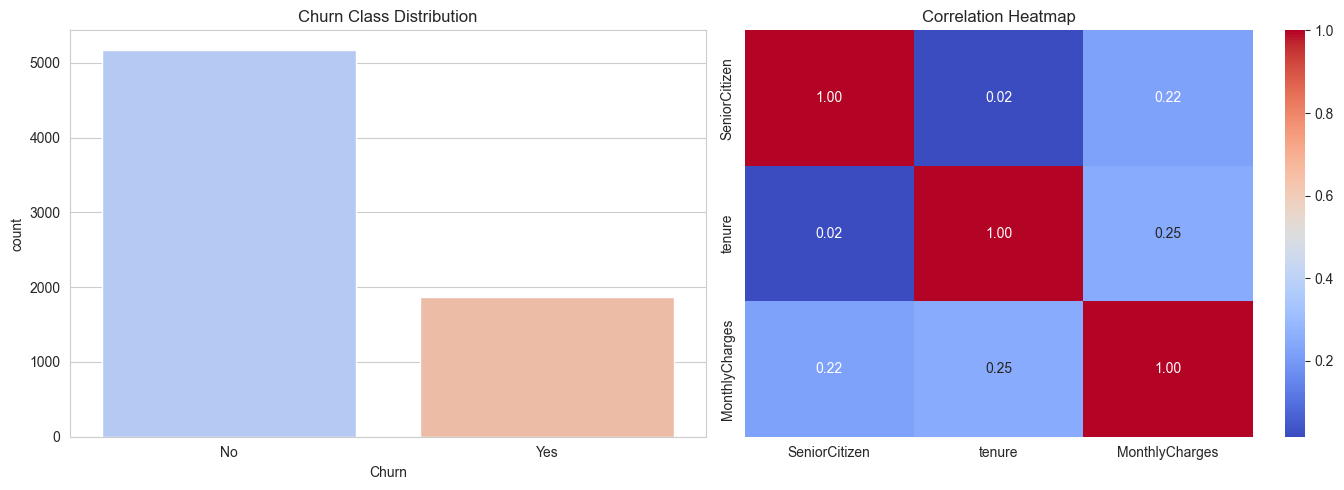

In [7]:
# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Churn', data=df, palette='coolwarm', ax=ax[0])
ax[0].set_title('Churn Class Distribution')

numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1])
    ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# 2. Data Cleaning & Preprocessing

In [8]:
# === Handle TotalCharges ===
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [9]:
# === Drop ID column ===
df = df.drop(columns=['customerID'], errors='ignore')

# === Encode target variable ===
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# === One hot encoding ===
X = df.drop('Churn', axis=1)
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)  # Convert categorical to numeric
numeric_cols = X.select_dtypes(include=[np.number]).columns

# 3. Train-Test Split + Handle Imbalance using SMOTE & Feature Scalling

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [11]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()

X_train_sm_scaled = scaler.fit_transform(X_train_sm[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

# 4. Model Evaluation Function

In [12]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, proba=True):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if proba and hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = y_pred

    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores)

    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print(confusion_matrix(y_test, y_pred), "\n")

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    }


# 5. Model Implementation

### Logistic Regression

=== Logistic Regression ===
Accuracy:  0.7189
Precision: 0.4807
Recall:    0.7344
F1-score:  0.5811
ROC-AUC:   0.8056
[[1107  445]
 [ 149  412]] 



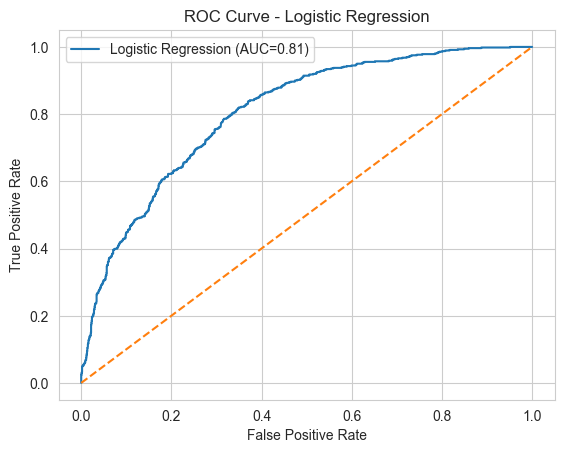

In [13]:
log_reg = LogisticRegression(max_iter=1000)

result_log = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_train_sm_scaled, y_train_sm,
    X_test_scaled, y_test
)

### Decision Tree

=== Decision Tree ===
Accuracy:  0.7094
Precision: 0.4599
Recall:    0.5419
F1-score:  0.4975
ROC-AUC:   0.6580
[[1195  357]
 [ 257  304]] 



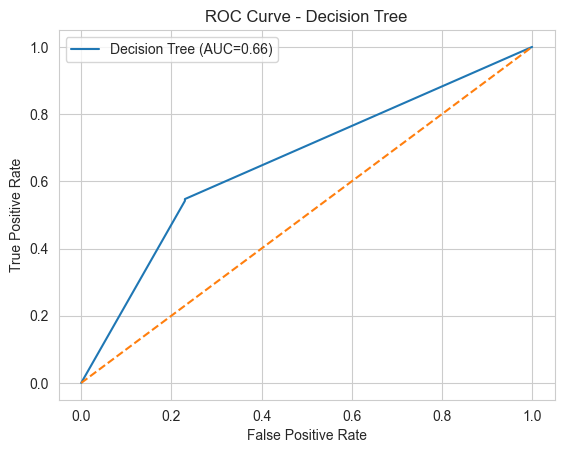

In [14]:
dt = DecisionTreeClassifier(random_state=42)

result_dt = evaluate_model(
    "Decision Tree",
    dt,
    X_train_sm, y_train_sm,
    X_test, y_test
)

### Random Forest

=== Random Forest ===
Accuracy:  0.7757
Precision: 0.5770
Recall:    0.5811
F1-score:  0.5790
ROC-AUC:   0.8162
[[1313  239]
 [ 235  326]] 



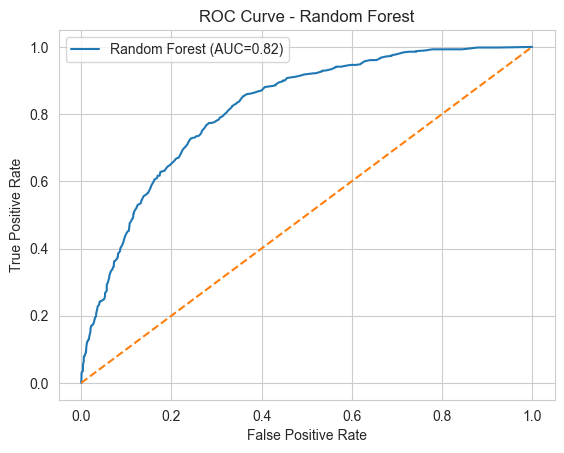

In [15]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

result_rf = evaluate_model(
    "Random Forest",
    rf,
    X_train_sm, y_train_sm,
    X_test, y_test
)

### XGBoost

=== XGBoost ===
Accuracy:  0.7724
Precision: 0.5712
Recall:    0.5722
F1-score:  0.5717
ROC-AUC:   0.8124
[[1311  241]
 [ 240  321]] 



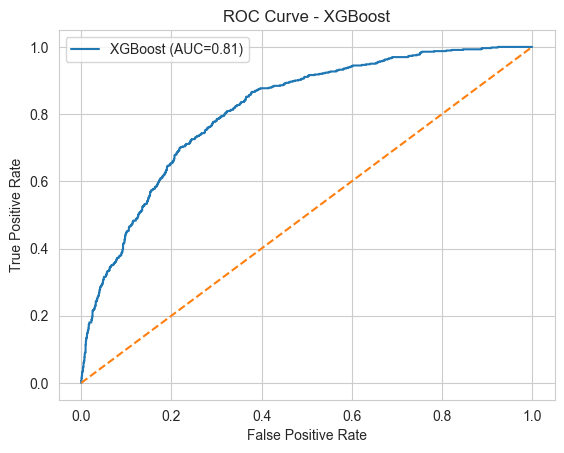

In [16]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

result_xgb = evaluate_model(
    "XGBoost",
    xgb,
    X_train_sm, y_train_sm,
    X_test, y_test
)

### SVM

=== SVM ===
Accuracy:  0.7269
Precision: 0.4908
Recall:    0.7611
F1-score:  0.5968
ROC-AUC:   0.7990
[[1109  443]
 [ 134  427]] 



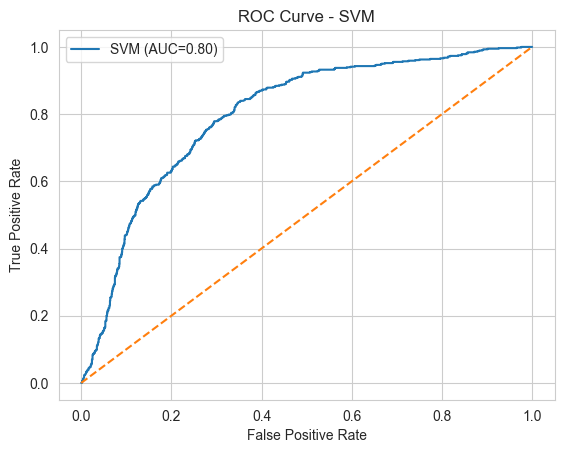

In [17]:
svm = SVC(kernel='rbf', probability=True, random_state=42)

result_svm = evaluate_model(
    "SVM",
    svm,
    X_train_sm_scaled, y_train_sm,
    X_test_scaled, y_test
)

## Additional Model

### K-Nearest Neighbors (KNN)

=== K-Nearest Neighbors ===
Accuracy:  0.7151
Precision: 0.4741
Recall:    0.6702
F1-score:  0.5554
ROC-AUC:   0.7647
[[1135  417]
 [ 185  376]] 



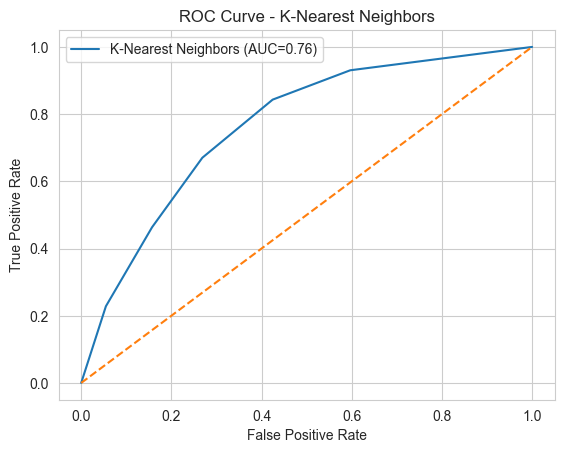

In [18]:
knn = KNeighborsClassifier(n_neighbors=5)

result_knn = evaluate_model(
    "K-Nearest Neighbors",
    knn,
    X_train_sm_scaled, y_train_sm,
    X_test_scaled, y_test
)

### LightGBM

=== LightGBM ===
Accuracy:  0.7728
Precision: 0.5709
Recall:    0.5811
F1-score:  0.5760
ROC-AUC:   0.8206
[[1307  245]
 [ 235  326]] 



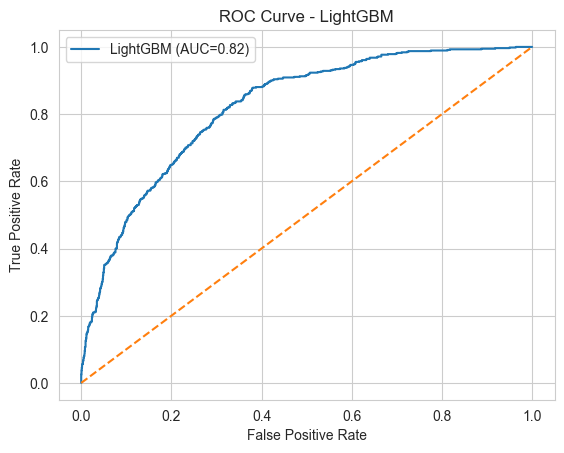

In [19]:
lgbm = LGBMClassifier(random_state=42, verbose=-1)

result_lgbm = evaluate_model(
    "LightGBM",
    lgbm,
    X_train_sm, y_train_sm,
    X_test, y_test
)

# 6. Compare All Model (Raw Baseline Performance)

In [20]:
results_df = pd.DataFrame([
    result_log,
    result_dt,
    result_rf,
    result_svm,
    result_xgb,
    result_knn,
    result_lgbm
])

results_df.sort_values(by="f1", ascending=False, ignore_index=True)

,model,accuracy,precision,recall,f1,roc_auc
0,SVM,0.726929,0.490805,0.761141,0.596785,0.798994
1,Logistic Regression,0.718883,0.480747,0.734403,0.581100,0.805640
2,Random Forest,0.775674,0.576991,0.581105,0.579041,0.816221
3,LightGBM,0.772835,0.570928,0.581105,0.575972,0.820599
4,XGBoost,0.772362,0.571174,0.572193,0.571683,0.812401
5,K-Nearest Neighbors,0.715097,0.474149,0.670232,0.555391,0.764743
6,Decision Tree,0.709418,0.459909,0.541889,0.497545,0.657991
